In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os

if os.path.basename(os.getcwd()) == 'plots':
    os.chdir('..')

import matplotlib.pyplot as plt
import mplhep as hep
from coffea.util import load
from plots import hep_plot as hplot
from plots.hep_plot import CMS_COLORS
import hist

hplot.setup(era="2024")

In [9]:
# ── Load MC samples ──────────────────────────────────────────────────────────
samples = {
    'TTbar':      load('./outputs/dy/TTbar_2024inclusive_noSyst.coffea'),
    # 'QCD':      load('./outputs/dy/QCD_2024inclusive_noSyst.coffea'),
    'ZPrime4000': load('./outputs/dy/ZPrime4000_1_2024_noSyst.coffea'),
}

# Convenience: colors and display labels per sample
sample_style = {
    'TTbar':      {'color': CMS_COLORS[0], 'label': r'$t\bar{t}$'},
    # 'QCD':      {'color': CMS_COLORS[1], 'label': 'QCD'},
    'ZPrime4000': {'color': CMS_COLORS[2], 'label': "Z' (4 TeV)"},
}

In [10]:
# ── Load data (sum over all eras) ─────────────────────────────────────────────
data_eras = ['2024C', '2024D', '2024E', '2024F', '2024G', '2024H']
data_outputs = [load(f'./outputs/dy/data_{era}_noSyst.coffea') for era in data_eras]

In [11]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def _plot_axis_name(h):
    axis_names = [axis.name for axis in h.axes]
    candidates = [name for name in axis_names if name not in {'systematic', 'anacat'}]
    if len(candidates) != 1:
        raise ValueError(f'Could not identify one plot axis from {axis_names}')
    return candidates[0]


def get_hist(output, var, anacat_id=None, syst='nominal'):
    """Fetch histogram `var` from a single MC output, project to 1D."""
    h = output[var][syst, ...]
    axis_name = _plot_axis_name(h)
    if anacat_id is not None:
        h = h[anacat_id, :].project(axis_name)
    else:
        h = h.project(axis_name)
    return h


def get_data_hist(var, anacat_id=None, syst='nominal'):
    """Fetch histogram `var` from all data eras and return their sum."""
    hists = []
    for o in data_outputs:
        h = o[var][syst, ...]
        axis_name = _plot_axis_name(h)
        if anacat_id is not None:
            h = h[anacat_id, :].project(axis_name)
        else:
            h = h.project(axis_name)
        hists.append(h)
    result = hists[0]
    for h in hists[1:]:
        result = result + h
    return result

In [12]:
# Inspect available keys and categories (use any sample as reference)
ref = next(iter(samples.values()))
print('Histogram keys:', list(ref.keys()))
print('Categories:', ref['analysisCategories'])

Histogram keys: ['ttbarmass', 'mtt_unwgt', 'mtt_vs_mt', 'numerator', 'denominator', 'jetmass', 'jetmsd', 'jetdy', 'jetmass1', 'jetmsd1', 'dR_min_jet2', 'jet0_pt', 'jet0_eta', 'jet0_phi', 'jet0_rapidity', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_rapidity', 'gen_mt', 'gen_mttbar', 'jet0_gen_dr', 'jet1_gen_dr', 'jet_mass_resolution', 'gen_jetmsd_reco_jetmsd', 'ht', 'cutflow', 'weights', 'systematics', 'event_list', 'truthstudy', 'analysisCategories']
Categories: {0: 'atcen', 1: 'atfwd', 2: '2tcen', 3: '2tfwd'}


## Per-sample distributions — central and forward categories

Each row: one variable.  
Left column: central (`|Δy| < 1`), right column: forward (`|Δy| > 1`).  
Each sample is drawn as a separate stepped histogram on the same axes.

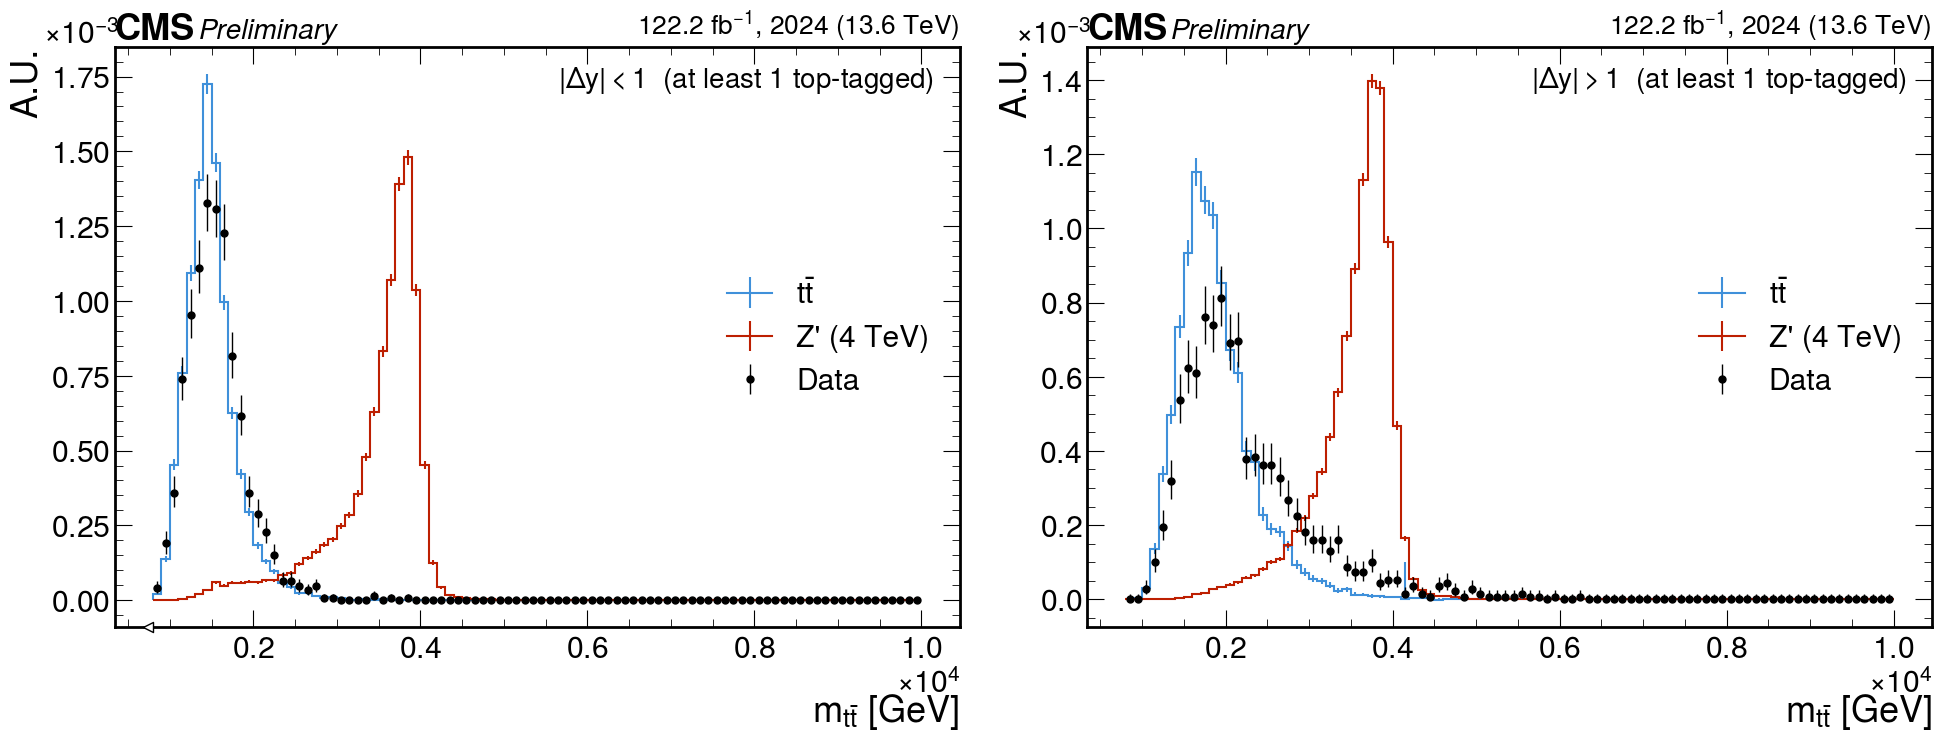

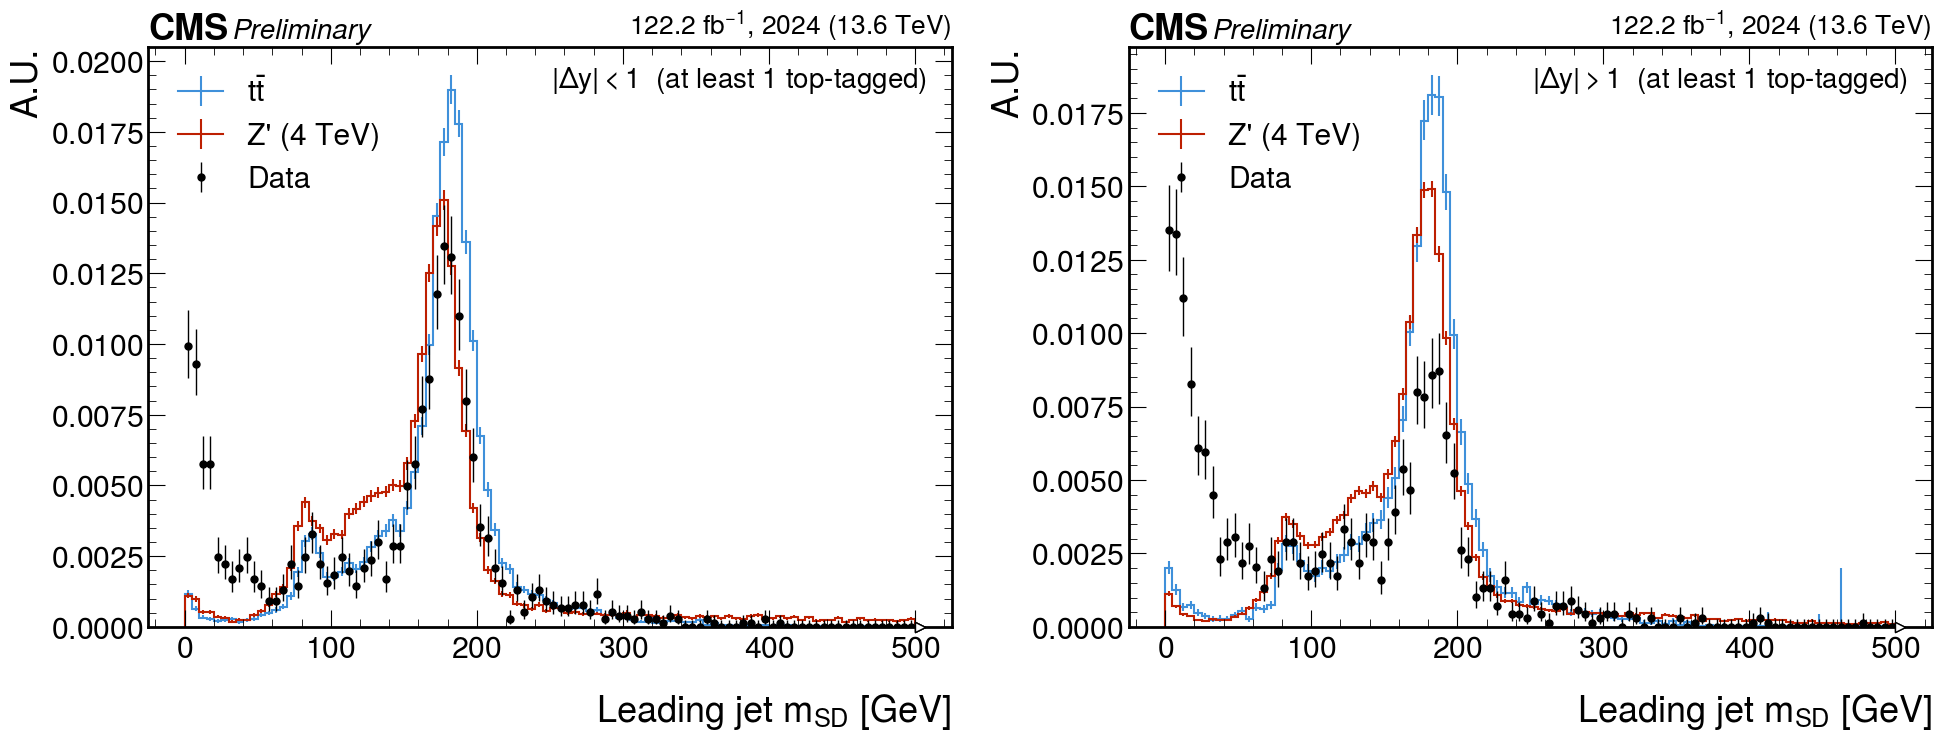

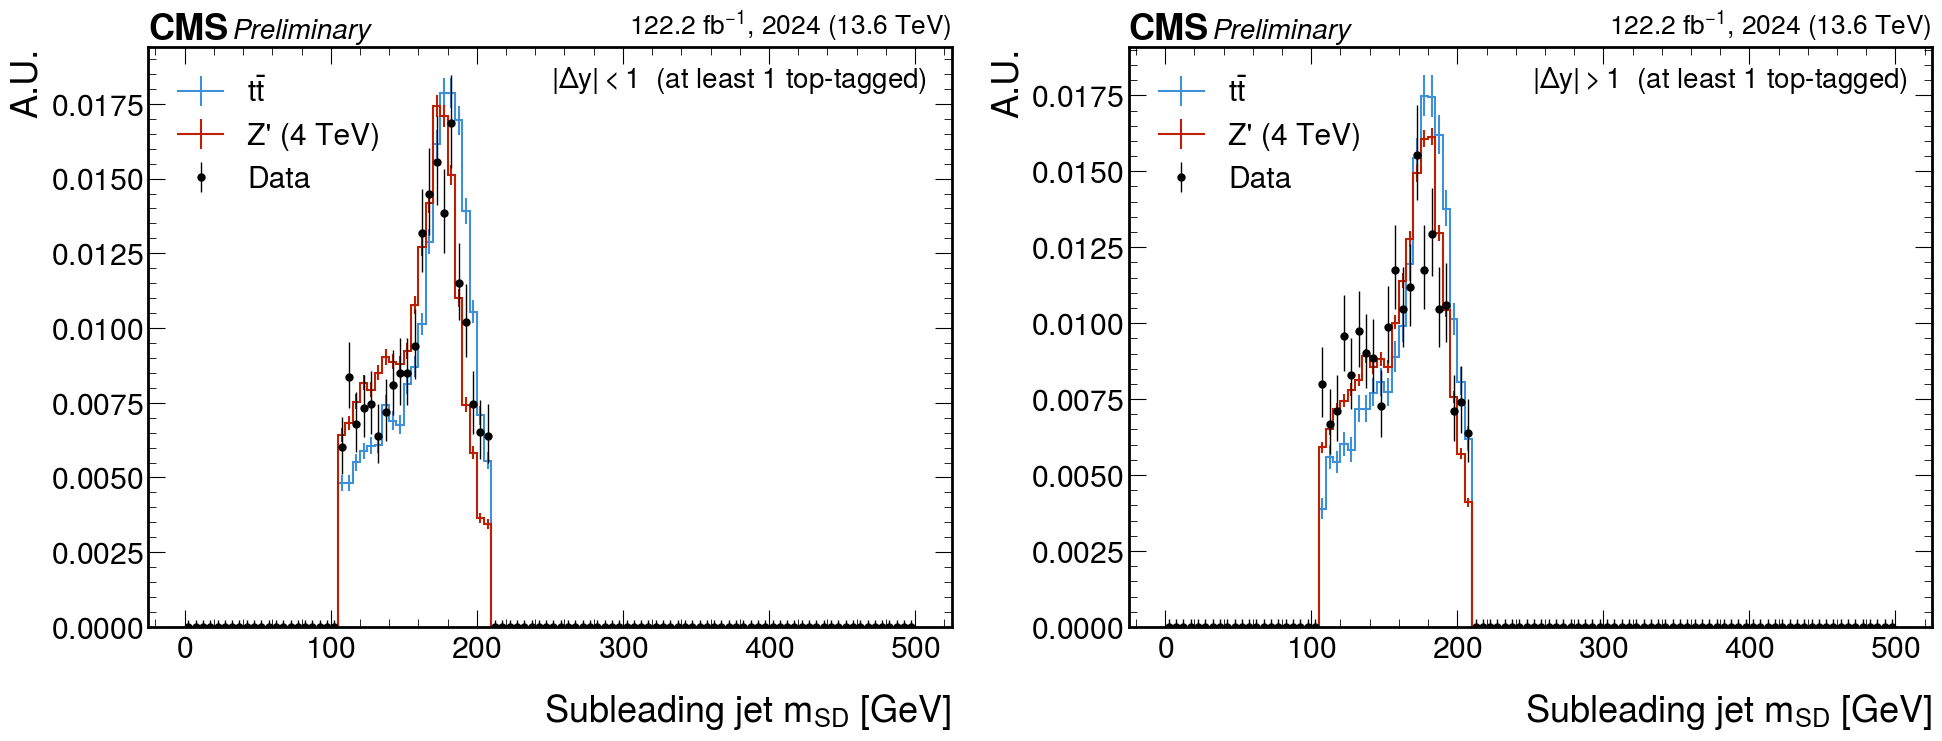

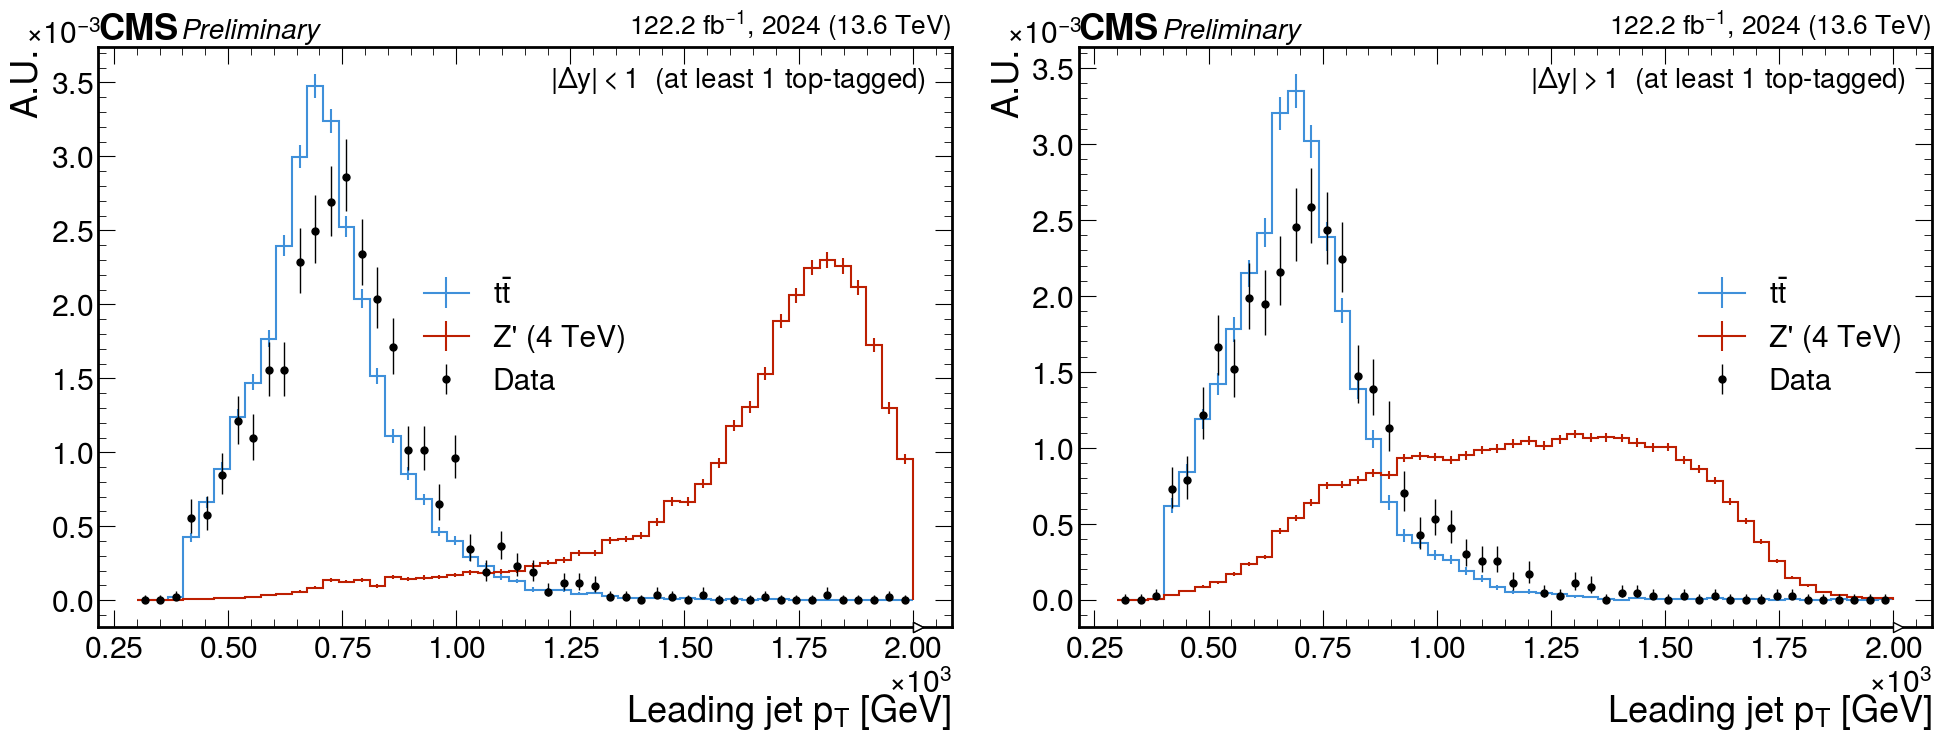

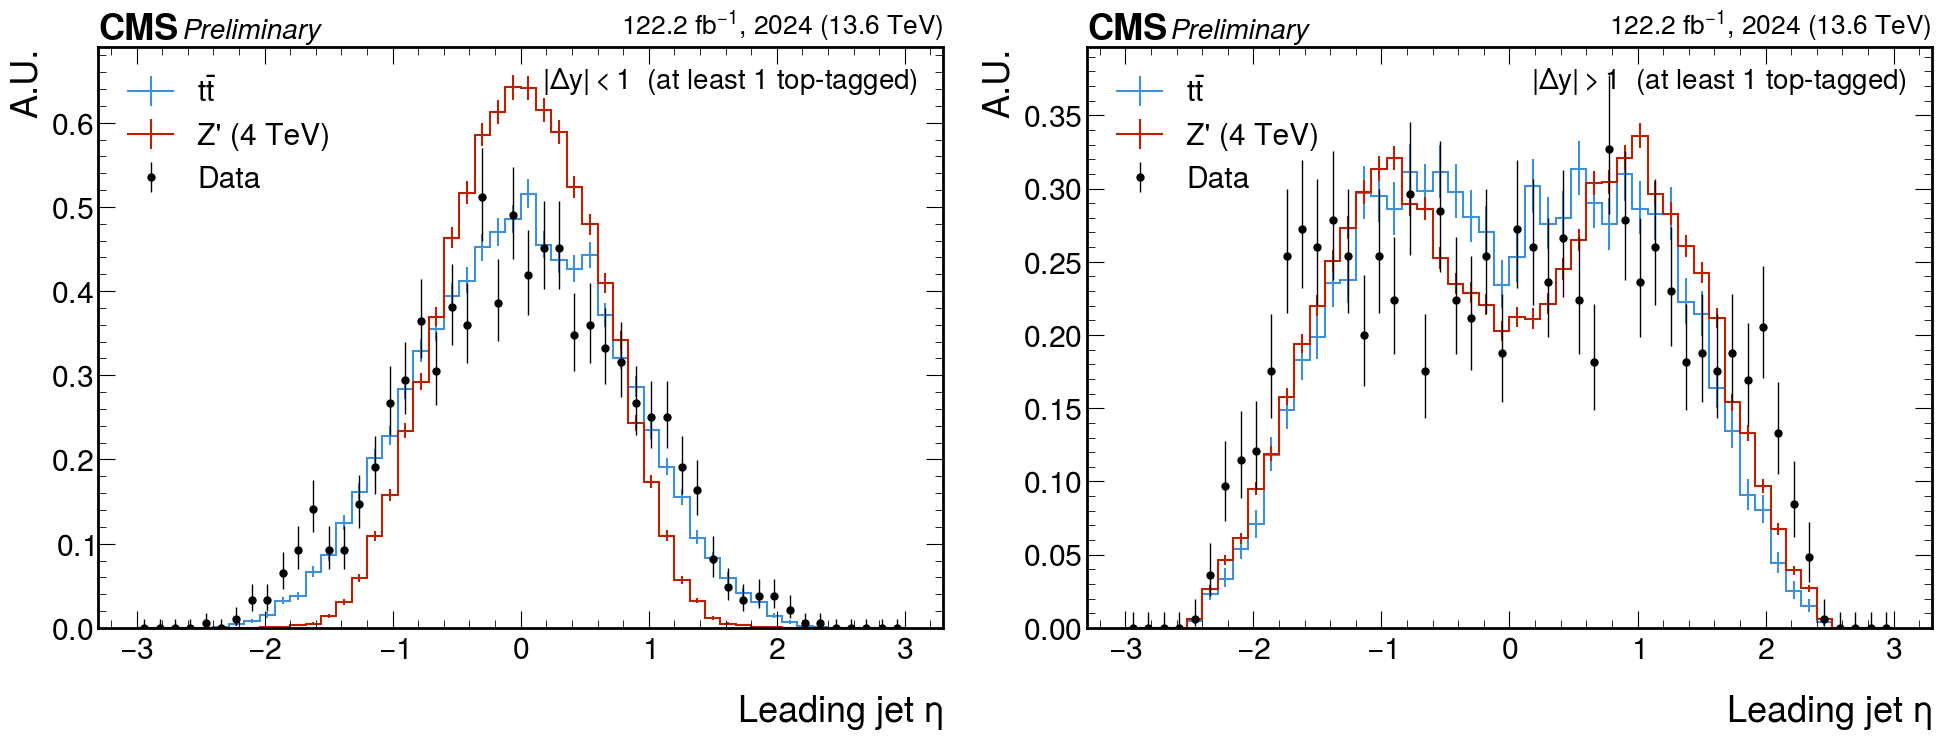

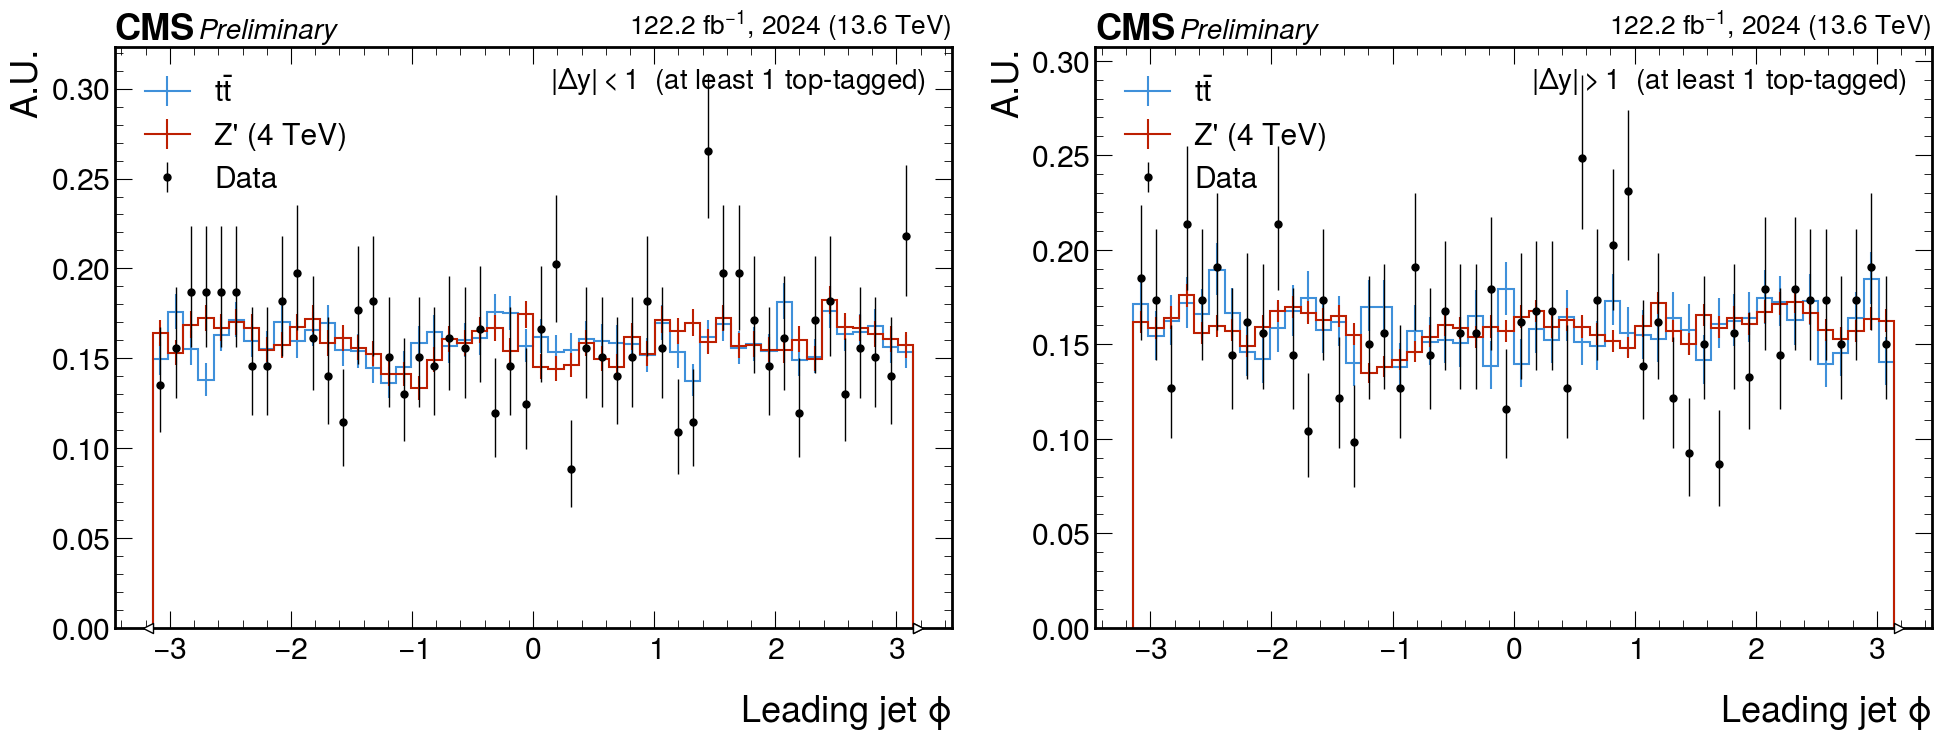

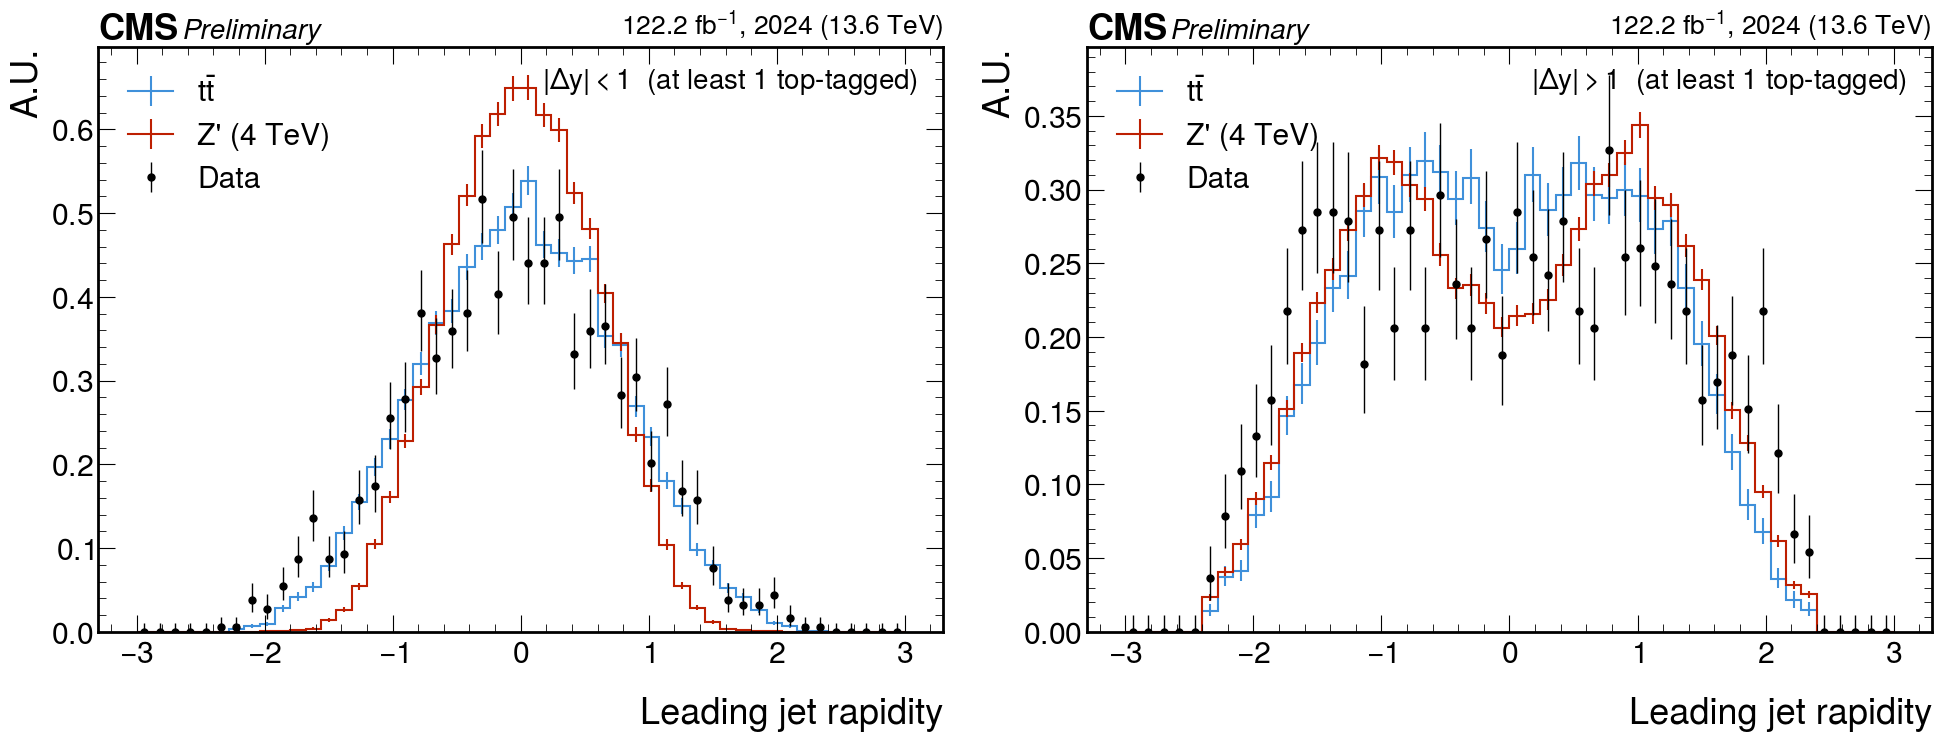

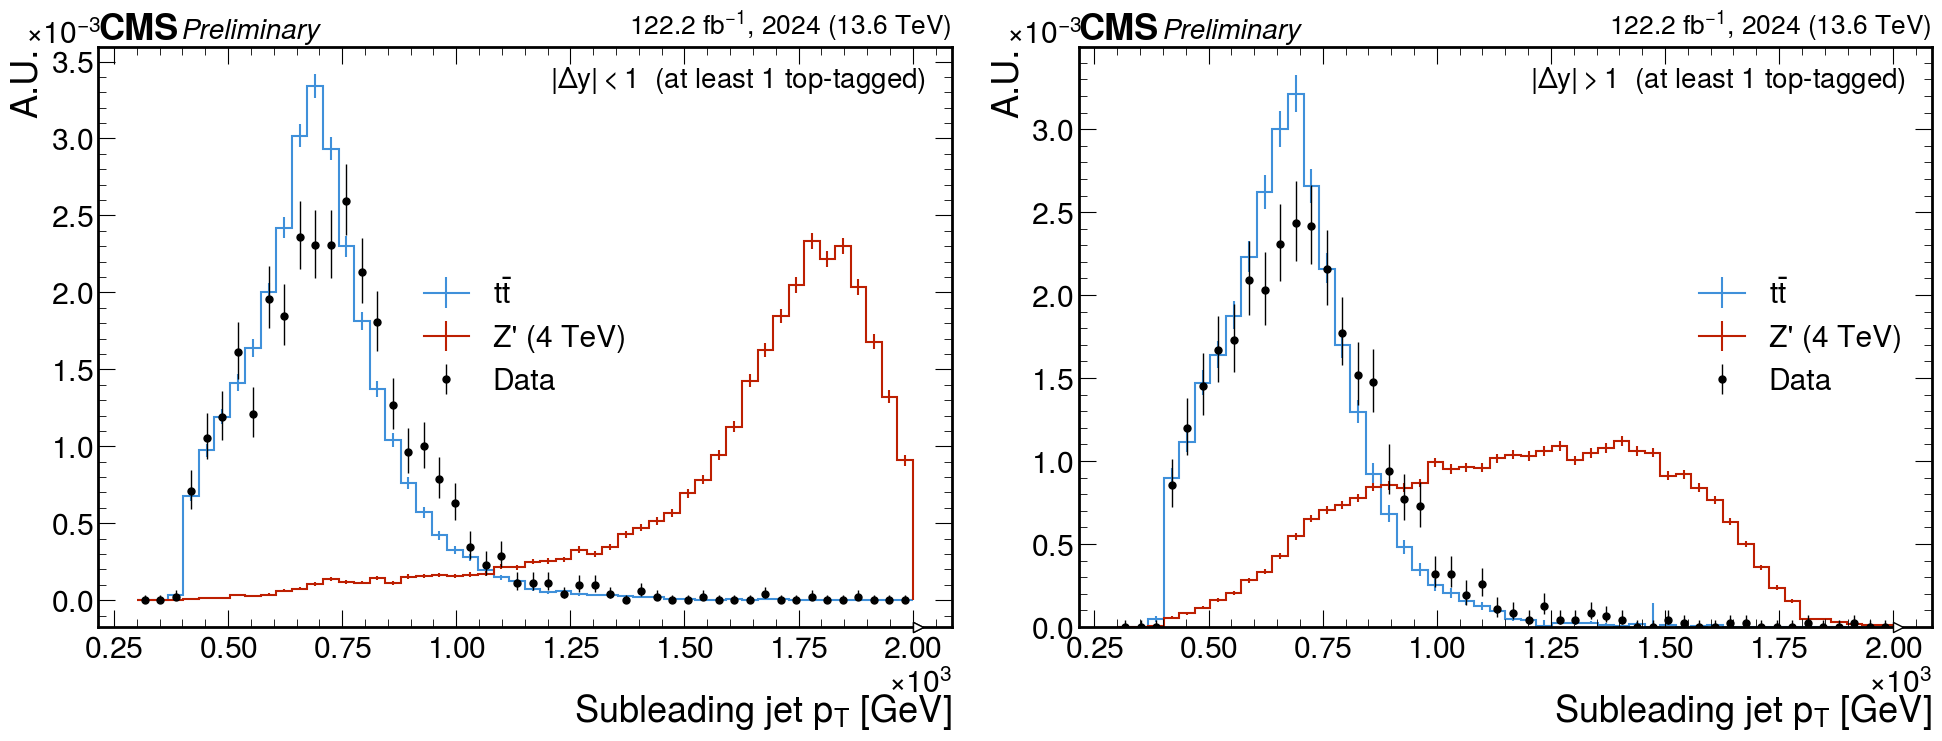

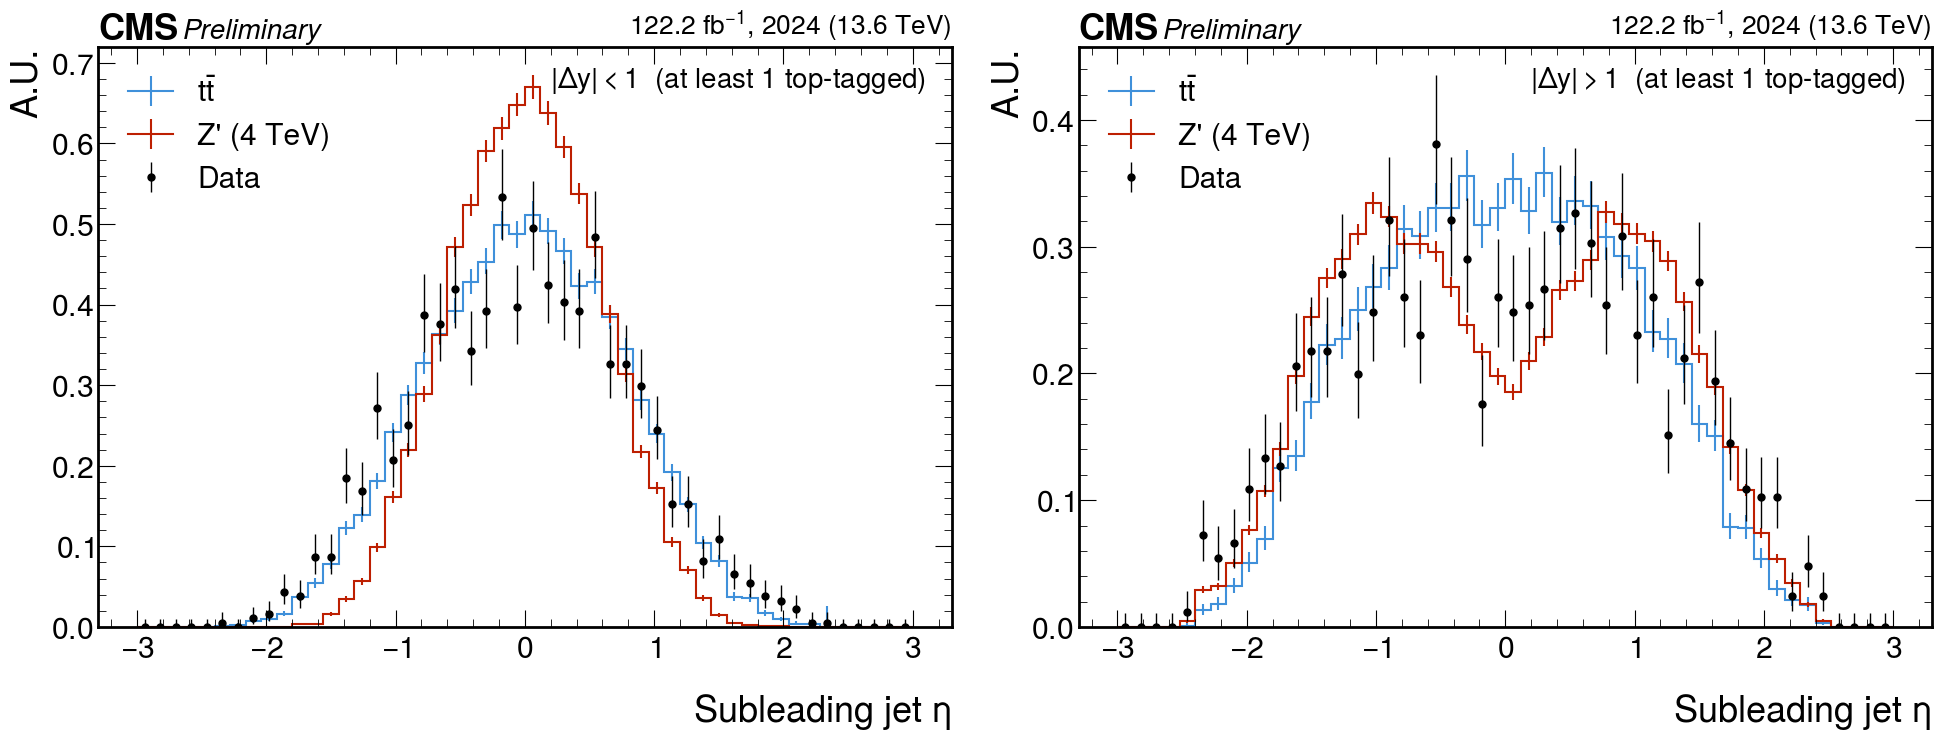

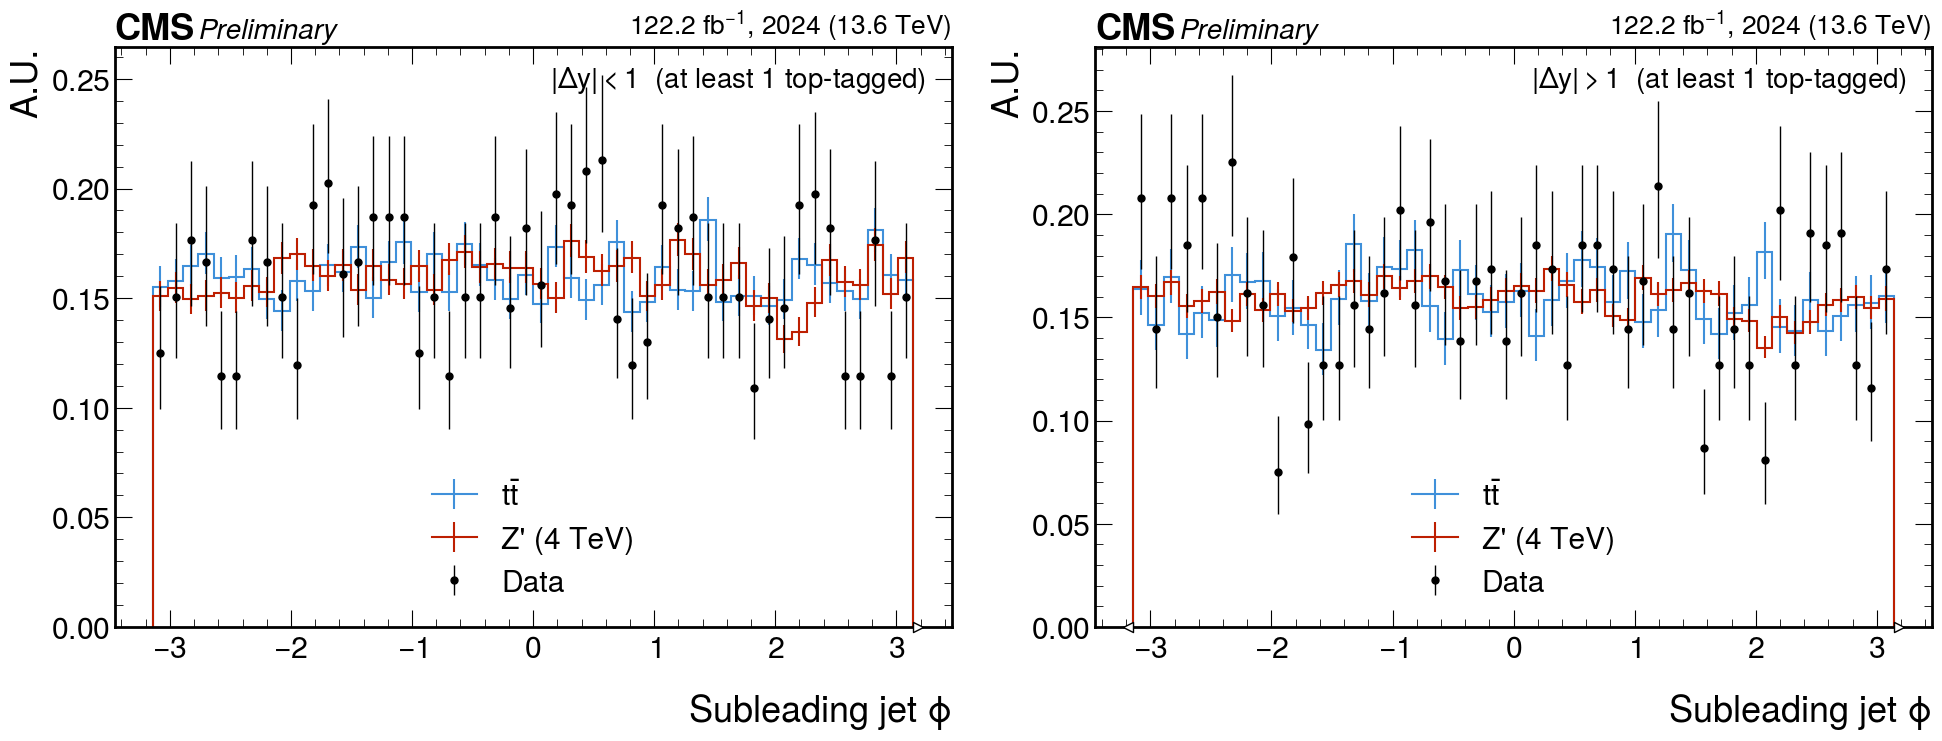

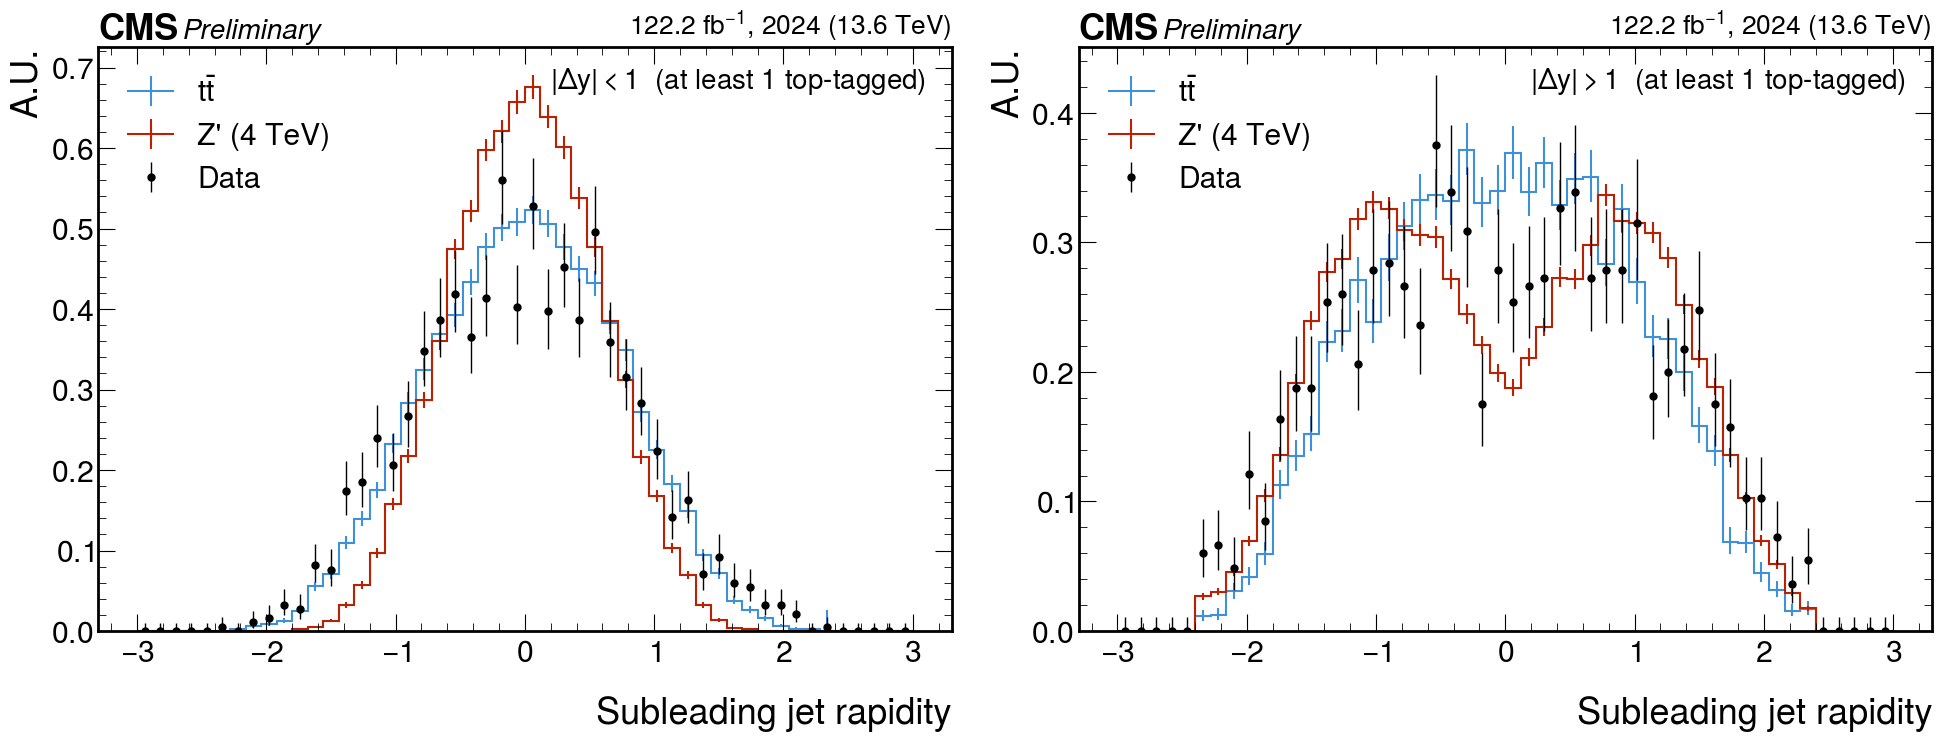

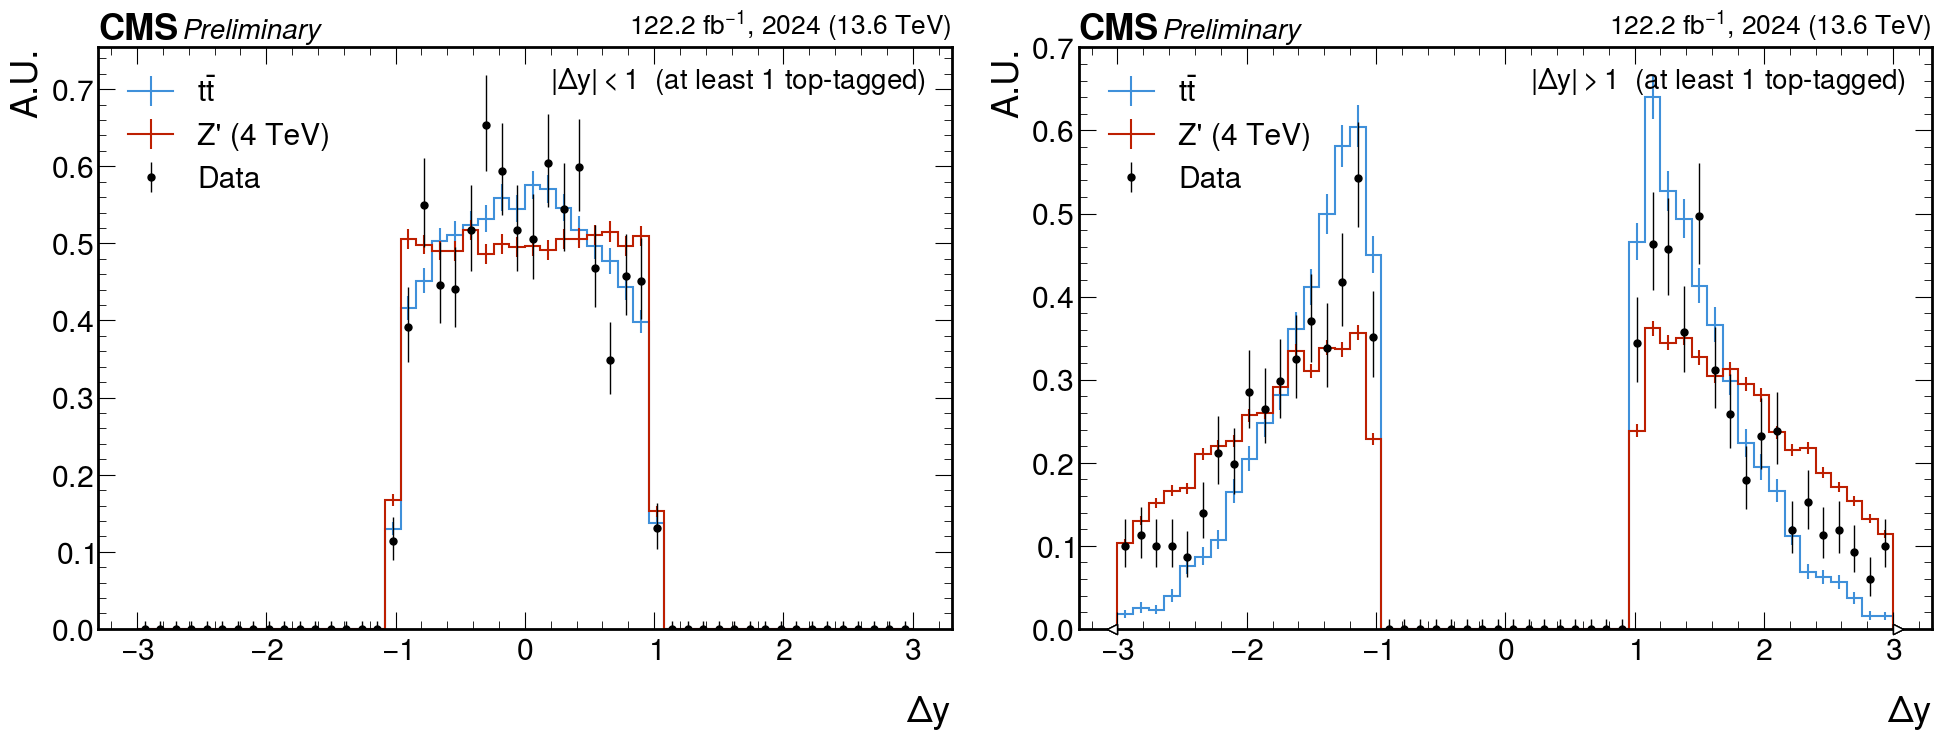

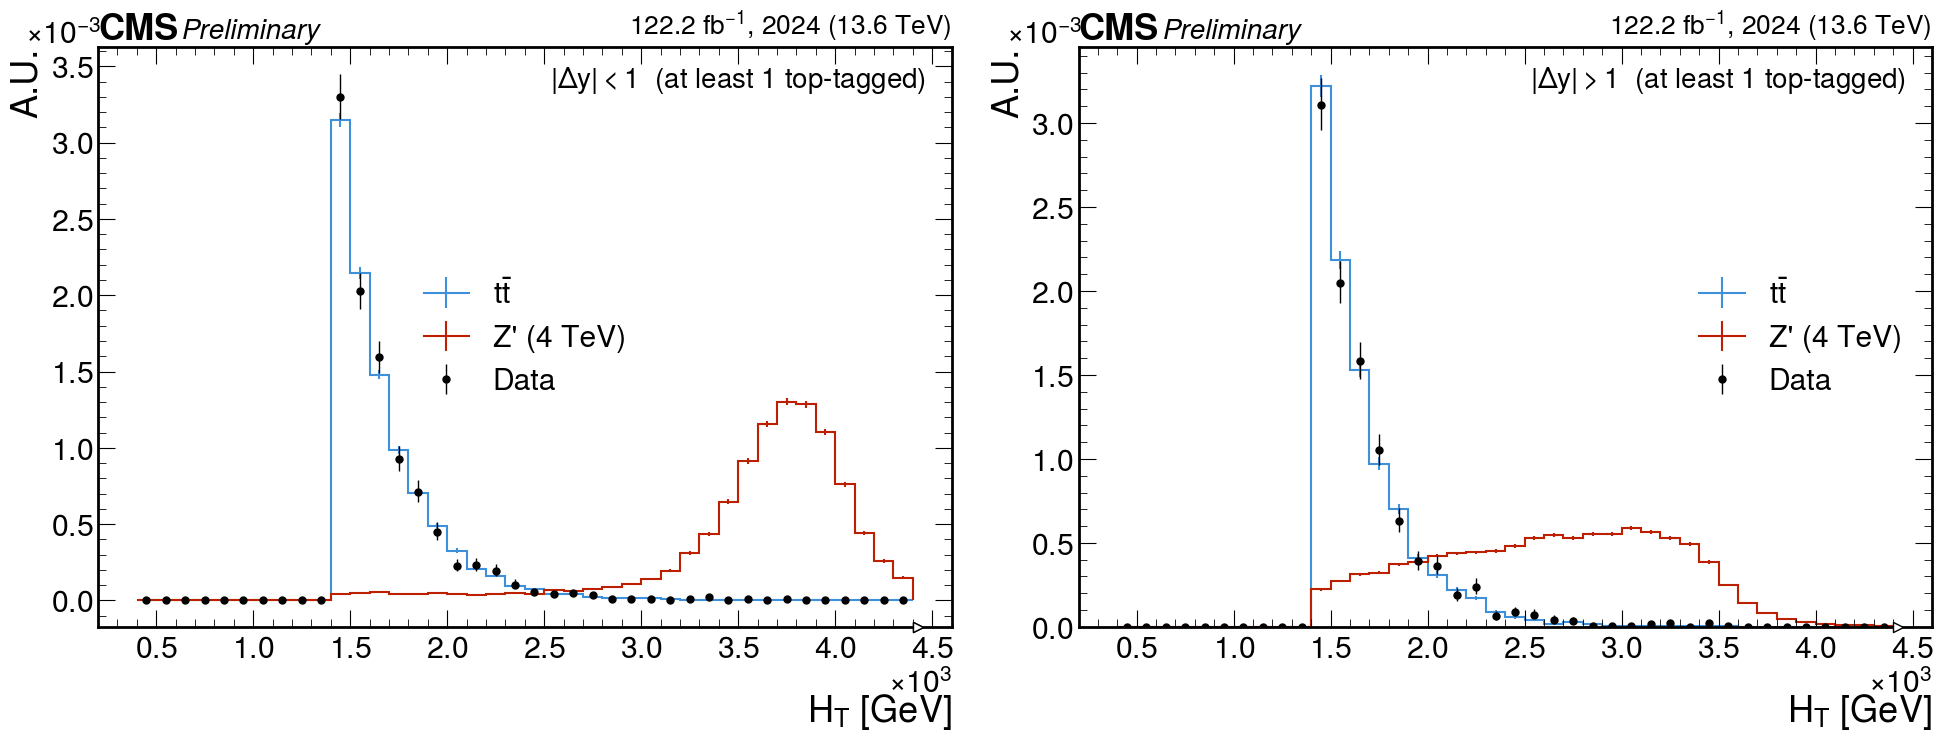

In [13]:
plot_specs = [
    ('ttbarmass',    r'$m_{t\bar{t}}$ [GeV]'),
    ('jetmsd',       r'Leading jet $m_{SD}$ [GeV]'),
    ('jetmsd1',      r'Subleading jet $m_{SD}$ [GeV]'),
    ('jet0_pt',      r'Leading jet $p_T$ [GeV]'),
    ('jet0_eta',     r'Leading jet $\eta$'),
    ('jet0_phi',     r'Leading jet $\phi$'),
    ('jet0_rapidity',r'Leading jet rapidity'),
    ('jet1_pt',      r'Subleading jet $p_T$ [GeV]'),
    ('jet1_eta',     r'Subleading jet $\eta$'),
    ('jet1_phi',     r'Subleading jet $\phi$'),
    ('jet1_rapidity',r'Subleading jet rapidity'),
    ('jetdy',        r'$\Delta y$'),
    ('ht',           r'$H_T$ [GeV]'),
]

# anacat IDs: 0=atcen, 1=atfwd, 2=2tcen, 3=2tfwd
cat_pairs = [
    (0, r'$|\Delta y| < 1$  (at least 1 top-tagged)'),
    (1, r'$|\Delta y| > 1$  (at least 1 top-tagged)'),
]

for var, xlabel in plot_specs:
    fig, axes = plt.subplots(1, len(cat_pairs), figsize=(10 * len(cat_pairs), 8))

    for ax, (cat_id, cat_label) in zip(axes, cat_pairs):
        # ── MC samples ──
        for sample_name, output in samples.items():
            style = sample_style[sample_name]
            try:
                h = get_hist(output, var, anacat_id=cat_id)
            except Exception:
                continue
            hep.histplot(h, ax=ax, histtype='step',
                         color=style['color'], label=style['label'], density=True)

        # ── Data (sum of all eras) ──
        try:
            h_data = get_data_hist(var, anacat_id=cat_id)
            hep.histplot(h_data, ax=ax, histtype='errorbar',
                         color='black', label='Data', density=True)
        except Exception:
            pass

        hplot.quick_label(xlabel=xlabel, data=True, ax=ax)
        ax.text(0.97, 0.97, cat_label, transform=ax.transAxes,
                ha='right', va='top', fontsize=20)
        ax.set_ylabel('A.U.')
        ax.set_xlabel(xlabel, labelpad=20)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Gen-level distributions (TTbar and ZPrime only)

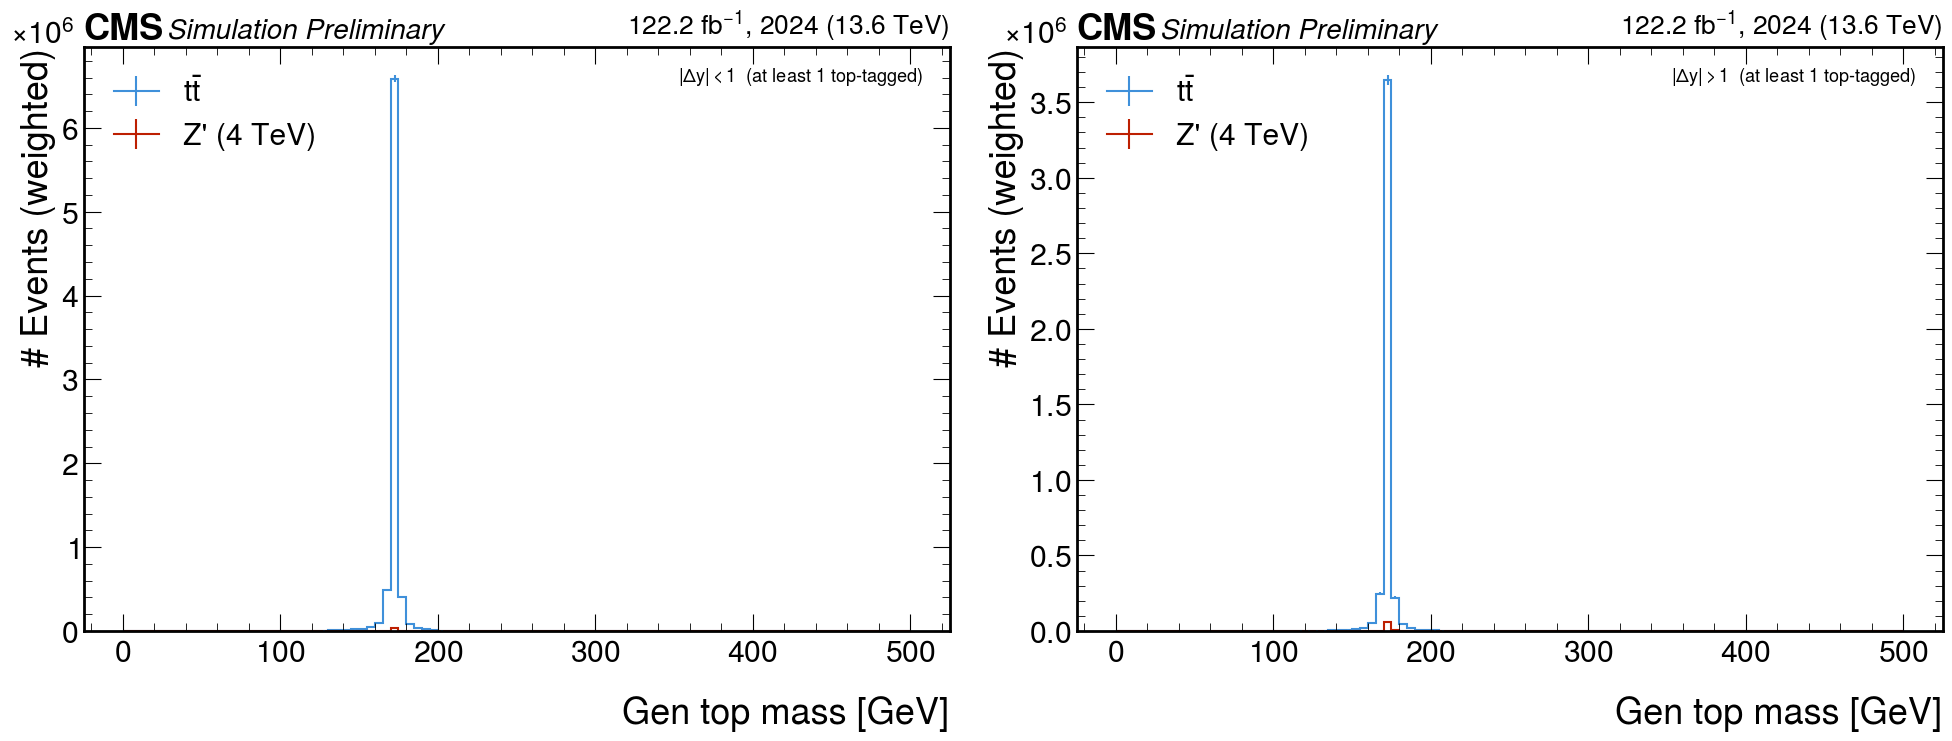

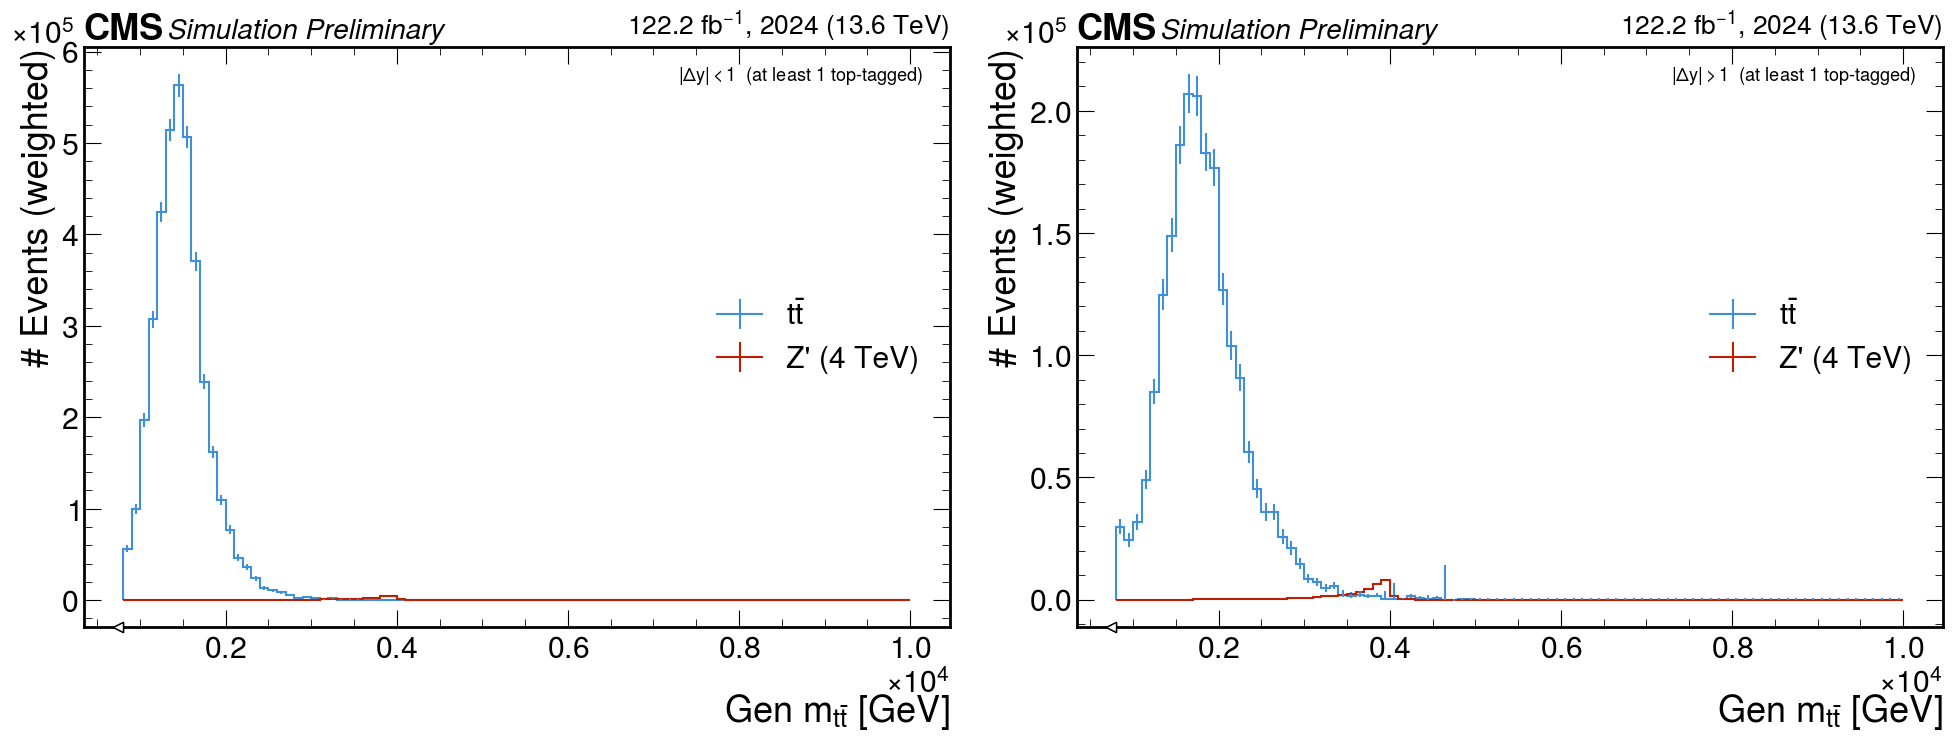

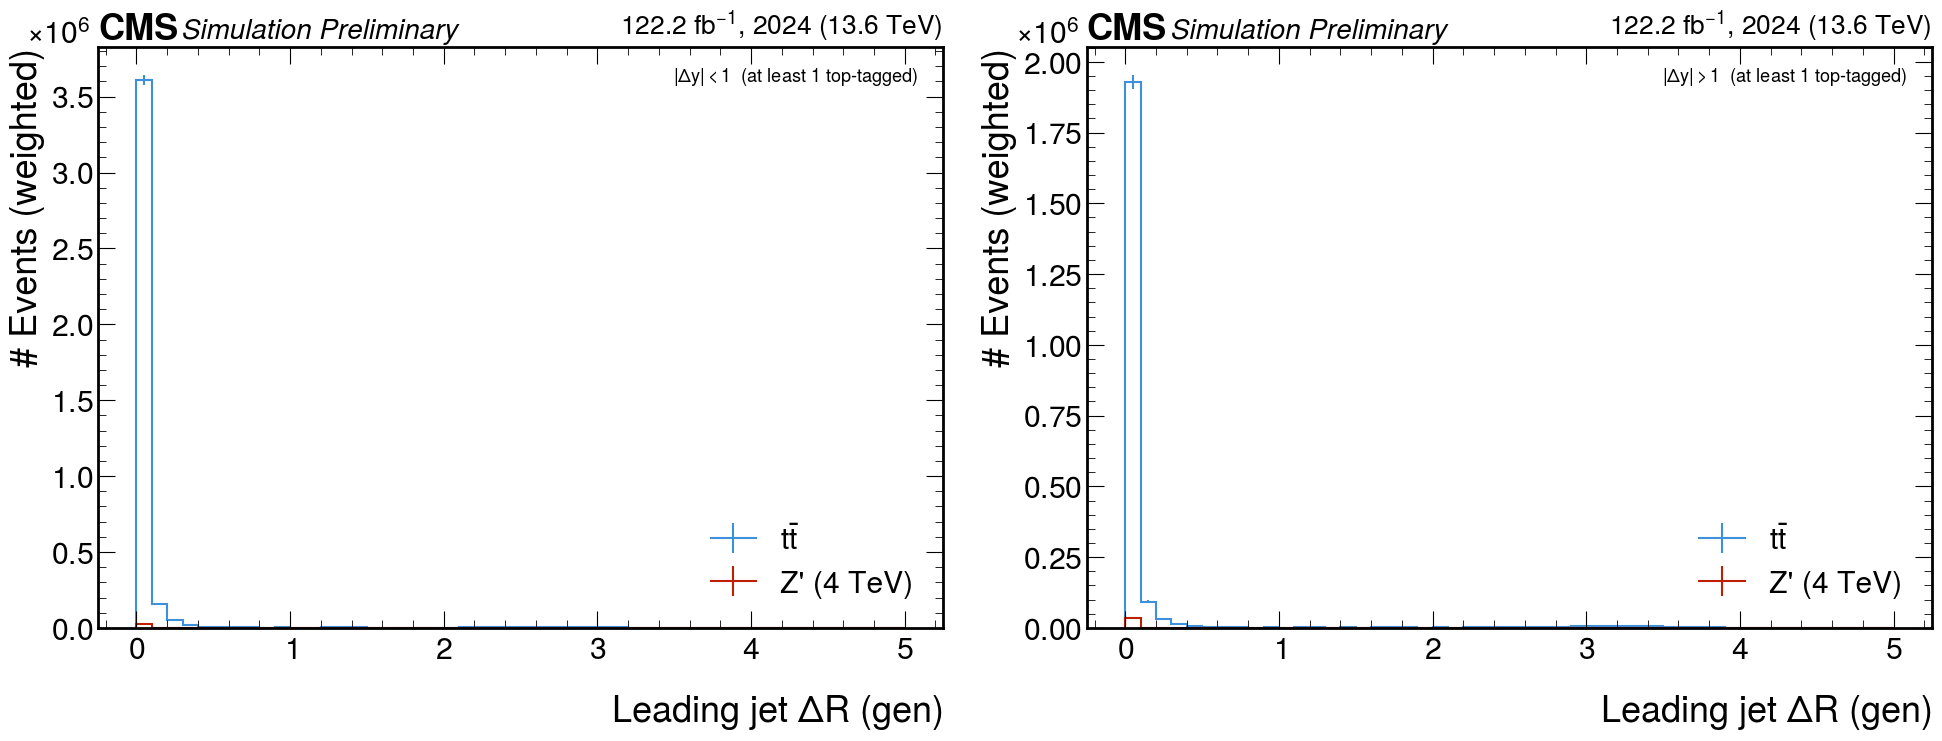

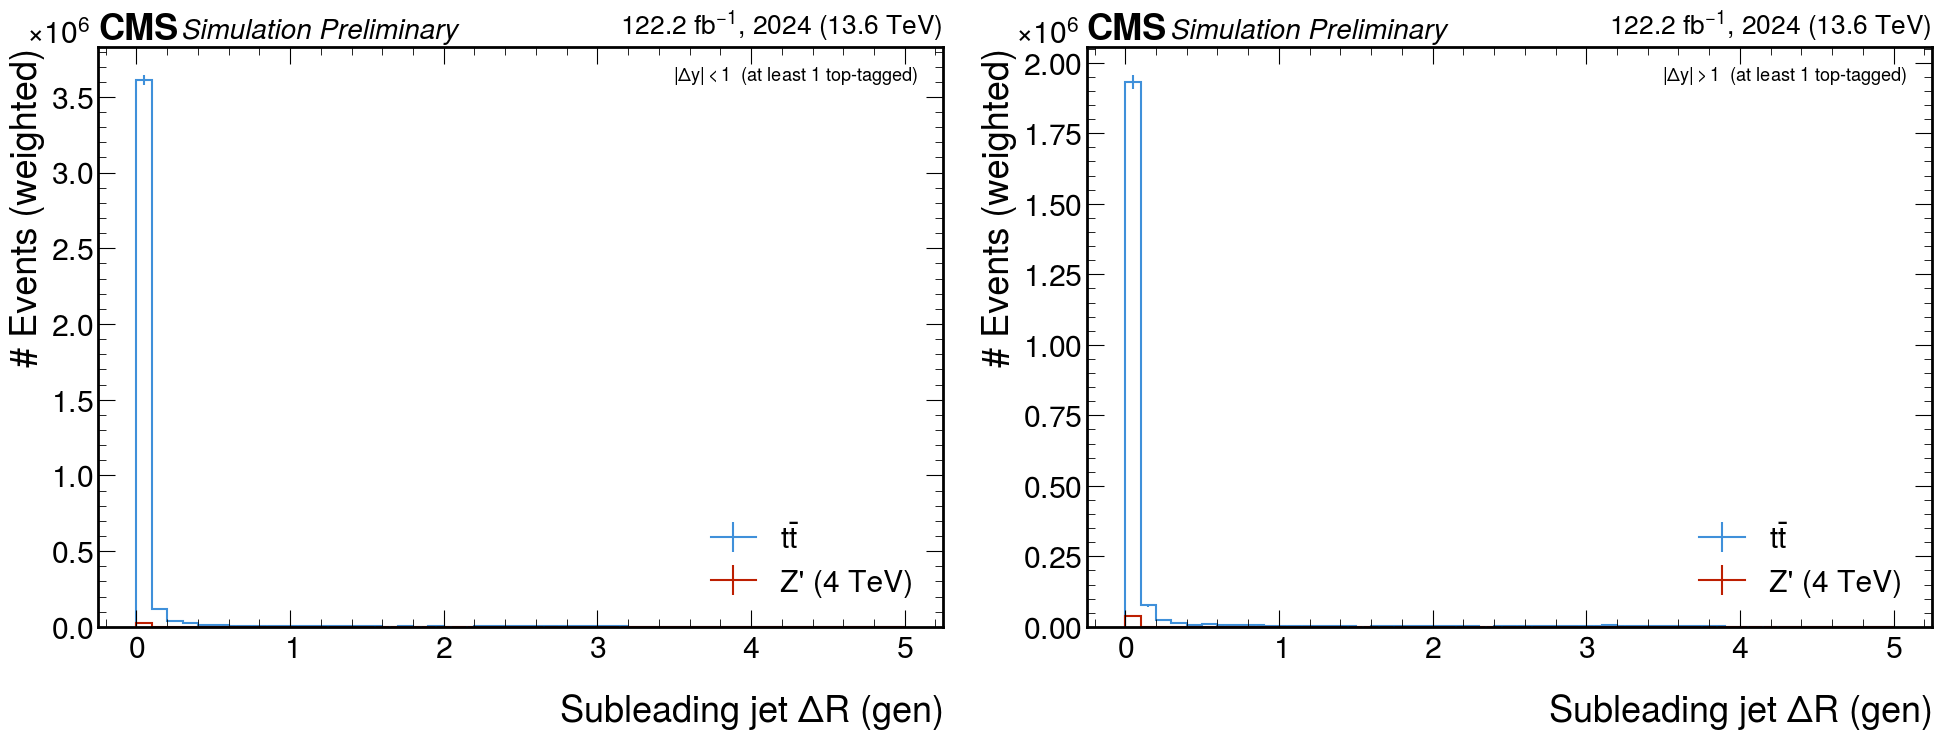

In [14]:
gen_specs = [
    ('gen_mt',      r'Gen top mass [GeV]'),
    ('gen_mttbar',  r'Gen $m_{t\bar{t}}$ [GeV]'),
    ('jet0_gen_dr', r'Leading jet $\Delta R$ (gen)'),
    ('jet1_gen_dr', r'Subleading jet $\Delta R$ (gen)'),
]

gen_samples = {k: v for k, v in samples.items() if k != 'QCD'}

for var, xlabel in gen_specs:
    fig, axes = plt.subplots(1, len(cat_pairs), figsize=(10 * len(cat_pairs), 8))

    for ax, (cat_id, cat_label) in zip(axes, cat_pairs):
        for sample_name, output in gen_samples.items():
            style = sample_style[sample_name]
            try:
                h = get_hist(output, var, anacat_id=cat_id)
            except Exception:
                continue
            hep.histplot(h, ax=ax, histtype='step',
                         color=style['color'], label=style['label'])

        hplot.quick_label(xlabel=xlabel, data=False, ax=ax)
        ax.text(0.97, 0.97, cat_label, transform=ax.transAxes,
                ha='right', va='top', fontsize=13)
        ax.set_ylabel('# Events (weighted)')
        ax.set_xlabel(xlabel, labelpad=20)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Cutflow

In [15]:
for sample_name, output in samples.items():
    print(f"── {sample_name} ──")
    print(output['cutflow'])
    print()

── TTbar ──
defaultdict_accumulator(<class 'int'>, {'all events 1': 472535695, 'all events': 472535695, 'sumw': np.float32(1.6412679e+11), 'sumw2': np.float32(5.7941873e+13), 'trigger': 5484358, 'htCut': 1641207, 'metfilter': 1634078, 'jetkincut': 1596692, 'twoFatJets': 1303541, 'after_eventCut': 1303541, 'after_ttbarcandCuts': 1255056, 'atcen': 19211, 'atfwd': 11027, '2tcen': 32994, '2tfwd': 19164})

── ZPrime4000 ──
defaultdict_accumulator(<class 'int'>, {'all events 1': 1985000, 'all events': 1985000, 'sumw': np.float32(1.985e+06), 'sumw2': np.float32(1.985e+06), 'trigger': 1727307, 'htCut': 1627050, 'metfilter': 1603925, 'jetkincut': 1603375, 'twoFatJets': 1540437, 'after_eventCut': 1540437, 'after_ttbarcandCuts': 1496048, 'atcen': 25598, 'atfwd': 38323, '2tcen': 35464, '2tfwd': 64063})

